# 🚆 Train Ridership Forecasting — ElasticNet Regression

This notebook builds an **ElasticNet regression model** to forecast train ridership and allocate the required number of trains per station and time period.

ElasticNet combines L1 (Lasso) and L2 (Ridge) regularization, making it well-suited for datasets with correlated features — which is expected here given lag and rolling features that overlap in meaning.

## Pipeline Overview
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading](#2-data-loading)
3. [Station Filtering](#3-station-filtering)
4. [Feature Engineering Functions](#4-feature-engineering-functions)
5. [Preprocessing Pipeline](#5-preprocessing-pipeline)
6. [Model Training with GridSearchCV](#6-model-training)
7. [Evaluation](#7-evaluation)
8. [Train Allocation](#8-train-allocation)
9. [Save Model](#9-save-model)

---
## 1. Setup & Imports

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
np.random.seed(42)

# Global plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

c:\Users\R.A.B\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde


---
## 2. Data Loading

In [3]:
df = pd.read_csv('../data/Ridership.csv')

# Parse a proper date column from Year + Month + Day
df['date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'] + '-' + df['Day'].astype(str)
)

print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (64369, 12)


,Year,Month,Day,Week Number,Corridor,Workday,Station,Period,Ridership,N_trains,Covid19,date
0,2019,January,1,1,Corridor_1,n,Station_1,Weekend/Holiday,174,3,0,2019-01-01
1,2019,January,1,1,Corridor_1,n,Station_2,Weekend/Holiday,378,10,0,2019-01-01
2,2019,January,1,1,Corridor_1,n,Station_3,Weekend/Holiday,599,12,0,2019-01-01
3,2019,January,1,1,Corridor_2,n,Station_4,Weekend/Holiday,2759,35,0,2019-01-01
4,2019,January,1,1,Corridor_2,n,Station_5,Weekend/Holiday,2629,36,0,2019-01-01
5,2019,January,1,1,Corridor_2,n,Station_3,Weekend/Holiday,27,1,0,2019-01-01
6,2019,January,1,1,Corridor_3,n,Station_4,Weekend/Holiday,3321,35,0,2019-01-01
7,2019,January,1,1,Corridor_3,n,Station_5,Weekend/Holiday,3721,36,0,2019-01-01
8,2019,January,1,1,Corridor_3,n,Station_3,Weekend/Holiday,17,1,0,2019-01-01
9,2019,January,2,1,Corridor_1,y,Station_1,AM Peak,3519,6,0,2019-01-02


---
## 3. Station Filtering

Stations with fewer than 30 records are grouped into an **`Other`** category.

> **Why?** Low-frequency stations lack enough observations to learn reliable patterns from.
> Grouping them avoids introducing high-cardinality noise while preserving their ridership contribution in the `Other` bucket.

In [4]:
MIN_RECORDS = 30

station_counts = df['Station'].value_counts()
valid_stations = station_counts[station_counts >= MIN_RECORDS].index

df_main = df[df['Station'].isin(valid_stations)].copy()
df_rare = df[~df['Station'].isin(valid_stations)].copy()
df_rare['Station'] = 'Other'

n_rare = len(station_counts) - len(valid_stations)
print(f'Valid stations : {len(valid_stations)}')
print(f'Rare stations grouped into "Other": {n_rare}')
print(f'Rows affected  : {len(df_rare)}')

# Recombine and sort chronologically
df = pd.concat([df_main, df_rare]).sort_values('date').reset_index(drop=True)

print(f'\nFinal dataset shape: {df.shape}')

Valid stations : 30
Rare stations grouped into "Other": 15
Rows affected  : 61

Final dataset shape: (64369, 12)


---
## 4. Feature Engineering Functions

All helper functions are defined here for reuse across model pipelines.

### 4.1 Time-Based Train/Test Split

In [5]:
def time_split_by_station(df, split_date):
    """
    Split the dataset into train and test sets using a time boundary.

    The split is performed per station to ensure temporal ordering is
    preserved within each group. Using a random split would leak future
    information into the training set.

    Parameters
    ----------
    df         : pd.DataFrame with a 'date' and 'Station' column
    split_date : str or pd.Timestamp — all rows before this date go to train

    Returns
    -------
    train_df, test_df : pd.DataFrame
    """
    train_list, test_list = [], []

    for station, g in df.groupby('Station'):
        g = g.sort_values('date')
        train_list.append(g[g['date'] < split_date])
        test_list.append(g[g['date'] >= split_date])

    return pd.concat(train_list), pd.concat(test_list)

### 4.2 Calendar Features

In [6]:
def add_calendar_features(df):
    """
    Add cyclical month encoding and day-of-week features.

    Cyclical sine/cosine encoding preserves the circular nature of months:
    December (12) and January (1) should be close in feature space,
    which a raw integer month value would not capture.

    New columns added:
        month       : integer month (1–12)
        month_sin   : sine encoding of month
        month_cos   : cosine encoding of month
        day_of_week : integer (0=Monday … 6=Sunday)
        is_weekend  : binary flag (1 if Saturday or Sunday)
    """
    df = df.copy()

    df['month']       = df['date'].dt.month
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

    return df

### 4.3 Lag & Rolling Features

In [7]:
def create_time_series_features(df):
    """
    Create lag and rolling mean features grouped by Station + Period.

    All features use shift(1) as the minimum lag to prevent data leakage:
    the model must not see the current day's ridership to predict it.

    New columns added:
        lag_1_period          : ridership 1 step ago (same station + period)
        lag_2_period          : ridership 2 steps ago
        lag_3_period          : ridership 3 steps ago
        rolling_mean_3_period : 3-step rolling mean (shifted by 1)
        rolling_mean_7_period : 7-step rolling mean (shifted by 1)

    Note: Must be called AFTER the train/test split to avoid leakage
    from test rows influencing train lag calculations.
    """
    df = df.copy()
    df = df.sort_values(by=['Station', 'date'])

    for lag in [1, 2, 3]:
        df[f'lag_{lag}_period'] = (
            df.groupby(['Station', 'Period'])['Ridership'].shift(lag)
        )

    df['rolling_mean_3_period'] = (
        df.groupby(['Station', 'Period'])['Ridership']
          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

    df['rolling_mean_7_period'] = (
        df.groupby(['Station', 'Period'])['Ridership']
          .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    )

    return df

### 4.4 Target Encoding for Station

In [8]:
def target_encode_station(train_df, test_df, target_col='Ridership'):
    """
    Time-safe target encoding for the Station column.

    Each station is replaced by its mean ridership value computed
    on the TRAINING set only. Applying train-derived statistics to
    the test set prevents data leakage.

    Unseen stations in the test set (e.g., 'Other') are filled with
    the global training mean as a fallback.

    Parameters
    ----------
    train_df   : pd.DataFrame — training data
    test_df    : pd.DataFrame — test data
    target_col : str — column to compute means from (default: 'Ridership')

    Returns
    -------
    train_df, test_df with 'Station_enc' column added
    """
    station_mean = train_df.groupby('Station')[target_col].mean()
    global_mean  = train_df[target_col].mean()

    train_df = train_df.copy()
    test_df  = test_df.copy()

    train_df['Station_enc'] = train_df['Station'].map(station_mean)
    test_df['Station_enc']  = test_df['Station'].map(station_mean).fillna(global_mean)

    return train_df, test_df

### 4.5 Preprocessor (Encoding + Scaling)

In [9]:
def build_preprocessor():
    """
    Build a ColumnTransformer that handles all feature preprocessing:

    - Categorical features (Corridor, Workday, Period):
        One-hot encoded with handle_unknown='ignore' to safely handle
        any unseen categories in the test set.

    - Numeric features (encoded station, calendar, lag, rolling):
        Standardized with StandardScaler (zero mean, unit variance).
        ElasticNet is sensitive to feature scale, so scaling is required.

    Returns
    -------
    sklearn ColumnTransformer (unfitted)
    """
    categorical_features = ['Corridor', 'Workday', 'Period']

    numeric_features = [
        'Station_enc',
        'month_sin', 'month_cos',
        'day_of_week', 'is_weekend',
        'Covid19',
        'lag_1_period', 'lag_2_period', 'lag_3_period',
        'rolling_mean_3_period', 'rolling_mean_7_period'
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', StandardScaler(), numeric_features)
        ],
        remainder='drop'  # drop unused columns (Year, Month, Day, etc.)
    )

    return preprocessor

### 4.6 Train Allocation

In [10]:
def allocate_trains(df, capacity=600, min_trains=1):
    """
    Calculate the number of trains needed based on predicted ridership.

    Uses ceiling division so that no passenger is left without a seat:
        required_trains = ceil(predicted_ridership / capacity)

    Parameters
    ----------
    df           : pd.DataFrame with a 'predicted_ridership' column
    capacity     : int — number of passengers per train (default: 600)
    min_trains   : int — minimum trains to always deploy (default: 1)

    Returns
    -------
    df with 'required_trains' column added
    """
    df = df.copy()
    df['required_trains'] = (
        np.ceil(df['predicted_ridership'] / capacity)
        .astype(int)
        .clip(lower=min_trains)
    )
    return df

---
## 5. Preprocessing Pipeline

All steps follow a strict **fit-on-train, apply-to-test** discipline to prevent data leakage.

In [11]:
# --- Step 1: Calendar features ---
df = add_calendar_features(df)

# --- Step 2: Time-based split ---
SPLIT_DATE = '2022-01-01'
train_df, test_df = time_split_by_station(df, split_date=SPLIT_DATE)
print(f'Train size : {len(train_df):,} rows')
print(f'Test  size : {len(test_df):,} rows')
print(f'Train date range: {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'Test  date range: {test_df["date"].min().date()}  → {test_df["date"].max().date()}')

Train size : 48,241 rows
Test  size : 16,128 rows
Train date range: 2019-01-01 → 2021-12-31
Test  date range: 2022-01-01  → 2022-12-31


In [12]:
# --- Step 3: Outlier removal using TRAIN statistics only ---
# Clipping outliers to median prevents extreme values from distorting
# the regression fit. Using TRAIN-derived bounds on TEST avoids leakage.

Q1 = train_df['Ridership'].quantile(0.25)
Q3 = train_df['Ridership'].quantile(0.75)
IQR = Q3 - Q1
lower_bound  = Q1 - 1.5 * IQR
upper_bound  = Q3 + 1.5 * IQR
median_value = train_df['Ridership'].median()

n_outliers_train = ((train_df['Ridership'] < lower_bound) | (train_df['Ridership'] > upper_bound)).sum()
n_outliers_test  = ((test_df['Ridership']  < lower_bound) | (test_df['Ridership']  > upper_bound)).sum()

train_df.loc[
    (train_df['Ridership'] < lower_bound) | (train_df['Ridership'] > upper_bound),
    'Ridership'
] = median_value

test_df.loc[
    (test_df['Ridership'] < lower_bound) | (test_df['Ridership'] > upper_bound),
    'Ridership'
] = median_value

print(f'Outliers replaced → Train: {n_outliers_train:,}  |  Test: {n_outliers_test:,}')
print(f'IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}]  |  Replacement median: {median_value:.1f}')

Outliers replaced → Train: 6,201  |  Test: 1,361
IQR bounds: [-1454.5, 2653.5]  |  Replacement median: 328.0


In [13]:
# --- Step 4: Lag & rolling features (created AFTER split to prevent leakage) ---
train_df = create_time_series_features(train_df)
test_df  = create_time_series_features(test_df)

# Drop rows with NaN values from lag operations (first few rows per group)
train_df = train_df.dropna().reset_index(drop=True)
test_df  = test_df.dropna().reset_index(drop=True)

print(f'After dropna → Train: {len(train_df):,}  |  Test: {len(test_df):,}')

After dropna → Train: 47,961  |  Test: 15,865


In [14]:
# --- Step 5: Target encoding for Station ---
train_df, test_df = target_encode_station(train_df, test_df)

# Inspect encoded station values (sorted by mean ridership)
station_enc_map = (
    train_df.groupby('Station')['Station_enc']
    .first()
    .sort_values(ascending=False)
)
print('Top 5 stations by encoded value (mean ridership):')
print(station_enc_map.head())

Top 5 stations by encoded value (mean ridership):
Station
Station_12    1154.877193
Station_15     955.966132
Station_13     758.966619
Station_23     672.981229
Station_16     671.491639
Name: Station_enc, dtype: float64


In [15]:
# --- Step 6: Separate features and target ---
DROP_COLS = ['Ridership', 'Station', 'date']

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df['Ridership']

X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df['Ridership']

# --- Step 7: Fit preprocessor on TRAIN, transform both splits ---
preprocessor = build_preprocessor()
X_train_enc  = preprocessor.fit_transform(X_train)
X_test_enc   = preprocessor.transform(X_test)

print(f'Encoded feature matrix shape → Train: {X_train_enc.shape}  |  Test: {X_test_enc.shape}')

Encoded feature matrix shape → Train: (47961, 25)  |  Test: (15865, 25)


---
## 6. Model Training

We use **GridSearchCV** with `TimeSeriesSplit` to tune the two key ElasticNet hyperparameters:

| Parameter | Role |
|-----------|------|
| `alpha` | Overall regularization strength (higher = more shrinkage) |
| `l1_ratio` | Balance between L1 (Lasso) and L2 (Ridge) — 0 = pure Ridge, 1 = pure Lasso |

In [16]:
param_grid = {
    'alpha'   : np.logspace(-3, 2, 6),   # [0.001, 0.01, 0.1, 1, 10, 100]
    'l1_ratio': [0.1, 0.5, 0.9]          # lean Ridge, balanced, lean Lasso
}

# TimeSeriesSplit respects temporal order — no future data leaks into validation folds
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator  = ElasticNet(max_iter=5000),
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_enc, y_train)

best_model = grid_search.best_estimator_

print(f'\nBest parameters : {grid_search.best_params_}')
print(f'Best CV RMSE    : {-grid_search.best_score_:.2f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters : {'alpha': np.float64(0.001), 'l1_ratio': 0.9}
Best CV RMSE    : 314.66


---
## 7. Evaluation

### 7.1 Test Set Metrics

In [17]:
y_pred = best_model.predict(X_test_enc)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mae  = np.mean(np.abs(y_test - y_pred))

print('=' * 42)
print('  ElasticNet Model — Test Performance')
print('=' * 42)
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  R²   : {r2:.4f}')
print('=' * 42)

  ElasticNet Model — Test Performance
  RMSE : 435.30
  MAE  : 275.79
  R²   : 0.4799


### 7.2 Actual vs. Predicted — Visual Check

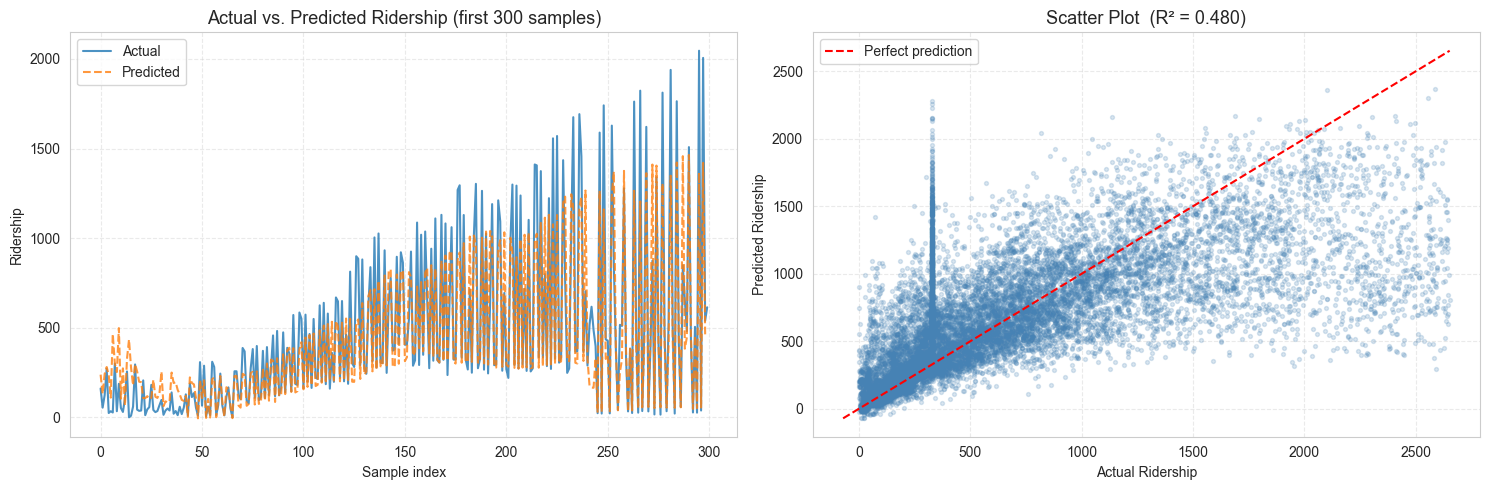

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Time series plot (first 300 samples) ---
n_show = 300
axes[0].plot(y_test.values[:n_show],  label='Actual',    alpha=0.8, linewidth=1.5)
axes[0].plot(y_pred[:n_show],         label='Predicted', alpha=0.8, linewidth=1.5, linestyle='--')
axes[0].set_title(f'Actual vs. Predicted Ridership (first {n_show} samples)', fontsize=13)
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Ridership')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Scatter plot ---
axes[1].scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())
axes[1].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='Perfect prediction')
axes[1].set_title(f'Scatter Plot  (R² = {r2:.3f})', fontsize=13)
axes[1].set_xlabel('Actual Ridership')
axes[1].set_ylabel('Predicted Ridership')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 7.3 Residual Analysis

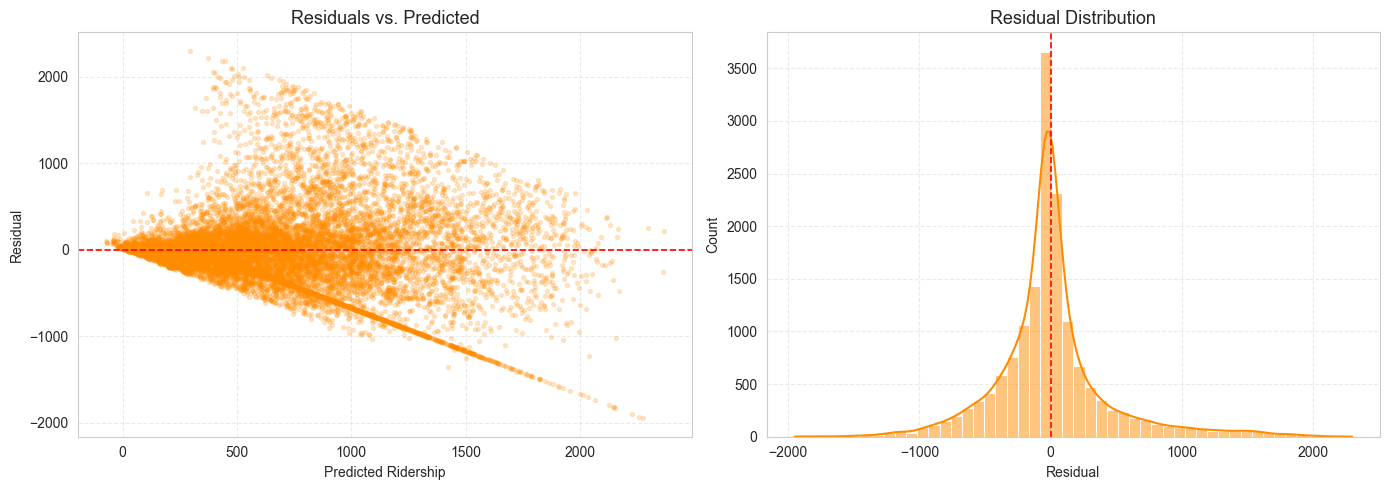

In [19]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs. predicted — check for heteroskedasticity
axes[0].scatter(y_pred, residuals, alpha=0.2, s=8, color='darkorange')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_title('Residuals vs. Predicted', fontsize=13)
axes[0].set_xlabel('Predicted Ridership')
axes[0].set_ylabel('Residual')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Residual distribution — check for normality
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linewidth=1.2, linestyle='--')
axes[1].set_title('Residual Distribution', fontsize=13)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 7.4 Per-Station Performance

   Station   RMSE      R2
Station_22  23.73 -0.6656
 Station_6  27.24  0.0188
Station_11  54.78  0.8970
 Station_8  70.57  0.0206
 Station_2  80.99  0.7454
Station_32  87.94  0.5401
Station_24  88.05  0.8308
 Station_7  96.19 -0.0038
Station_31 138.17  0.5343
     Other 159.09 -2.7917
Station_13 167.29 -0.1403
Station_26 219.58 -2.6502
Station_21 265.62  0.7189
Station_23 304.60  0.5764
 Station_9 349.91  0.6903
 Station_1 360.07  0.6733
Station_30 397.88  0.4630
 Station_4 401.37  0.4850
Station_12 456.35 -0.3015
Station_19 472.93  0.5837
Station_17 495.45  0.2680
 Station_5 528.80  0.3934
Station_43 544.41  0.3722
 Station_3 578.25  0.1465


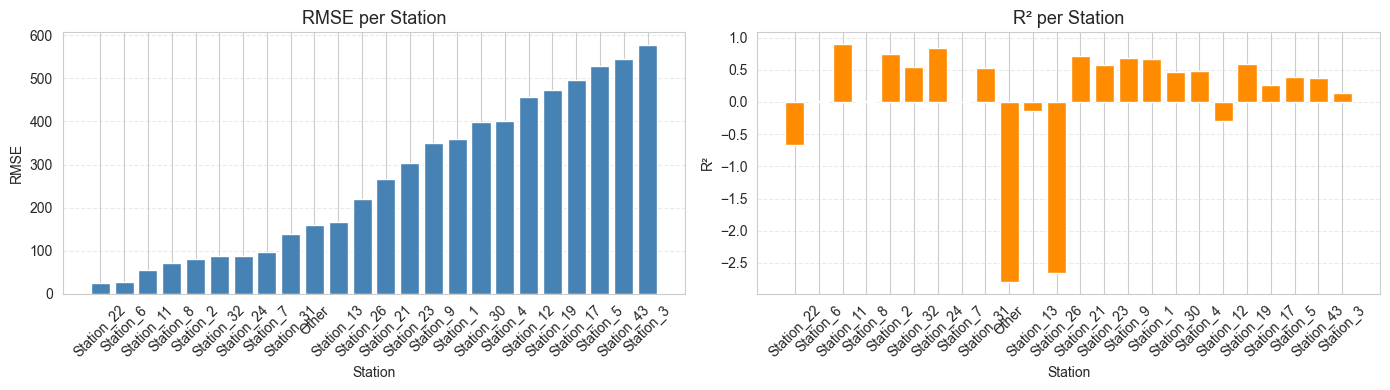

In [20]:
results_df = test_df.copy()
results_df['predicted_ridership'] = y_pred

station_metrics = []
for station, grp in results_df.groupby('Station'):
    s_rmse = np.sqrt(mean_squared_error(grp['Ridership'], grp['predicted_ridership']))
    s_r2   = r2_score(grp['Ridership'], grp['predicted_ridership'])
    station_metrics.append({'Station': station, 'RMSE': round(s_rmse, 2), 'R2': round(s_r2, 4)})

metrics_df = pd.DataFrame(station_metrics).sort_values('RMSE')
print(metrics_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(metrics_df['Station'], metrics_df['RMSE'], color='steelblue')
axes[0].set_title('RMSE per Station', fontsize=13)
axes[0].set_xlabel('Station')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].bar(metrics_df['Station'], metrics_df['R2'], color='darkorange')
axes[1].set_title('R² per Station', fontsize=13)
axes[1].set_xlabel('Station')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 7.5 Top Feature Importances

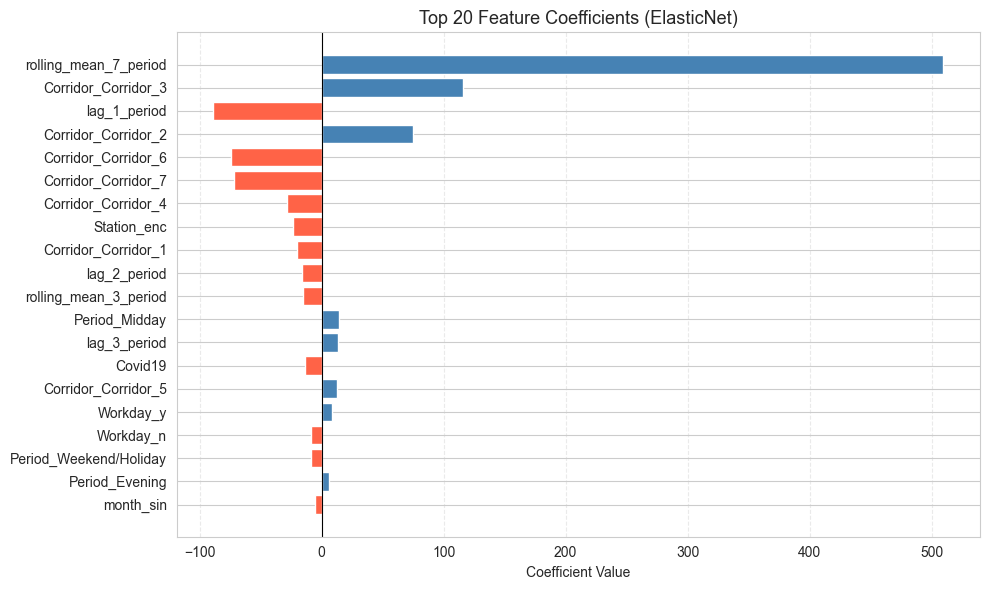

In [21]:
# Recover feature names from the ColumnTransformer
cat_feature_names = (
    preprocessor
    .named_transformers_['cat']
    .get_feature_names_out(['Corridor', 'Workday', 'Period'])
    .tolist()
)
num_feature_names = [
    'Station_enc', 'month_sin', 'month_cos', 'day_of_week', 'is_weekend',
    'Covid19', 'lag_1_period', 'lag_2_period', 'lag_3_period',
    'rolling_mean_3_period', 'rolling_mean_7_period'
]
all_feature_names = cat_feature_names + num_feature_names

# ElasticNet coefficients as a proxy for feature importance
coef_df = pd.DataFrame({
    'Feature'    : all_feature_names,
    'Coefficient': best_model.coef_
})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_title('Top 20 Feature Coefficients (ElasticNet)', fontsize=13)
ax.set_xlabel('Coefficient Value')
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 8. Train Allocation

Using predicted ridership to determine the number of trains required per station and time period:

$$\text{required\_trains} = \left\lceil \frac{\text{predicted\_ridership}}{\text{capacity}} \right\rceil$$

In [22]:
TRAIN_CAPACITY = 600  # passengers per train

results_df = allocate_trains(results_df, capacity=TRAIN_CAPACITY, min_trains=1)

# Summarise by station + date + period
allocation_summary = (
    results_df
    .groupby(['Station', 'date', 'Period'], as_index=False)
    .agg(
        predicted_ridership=('predicted_ridership', 'sum'),
        required_trains=('required_trains', 'max')
    )
)

print(f'Allocation summary shape: {allocation_summary.shape}')
allocation_summary.head(10)

Allocation summary shape: (11307, 5)


,Station,date,Period,predicted_ridership,required_trains
0,Other,2022-06-18,Weekend/Holiday,237.912828,1
1,Other,2022-07-01,Weekend/Holiday,130.671763,1
2,Other,2022-07-09,Weekend/Holiday,523.019877,1
3,Other,2022-07-16,Weekend/Holiday,236.462299,1
4,Other,2022-07-20,Evening,109.925996,1
5,Other,2022-07-26,Midday,464.425041,1
6,Other,2022-07-30,Weekend/Holiday,302.234236,1
7,Other,2022-08-13,Weekend/Holiday,252.617240,1
8,Other,2022-08-15,Midday,497.989926,1
9,Other,2022-08-22,PM Peak,104.101863,1


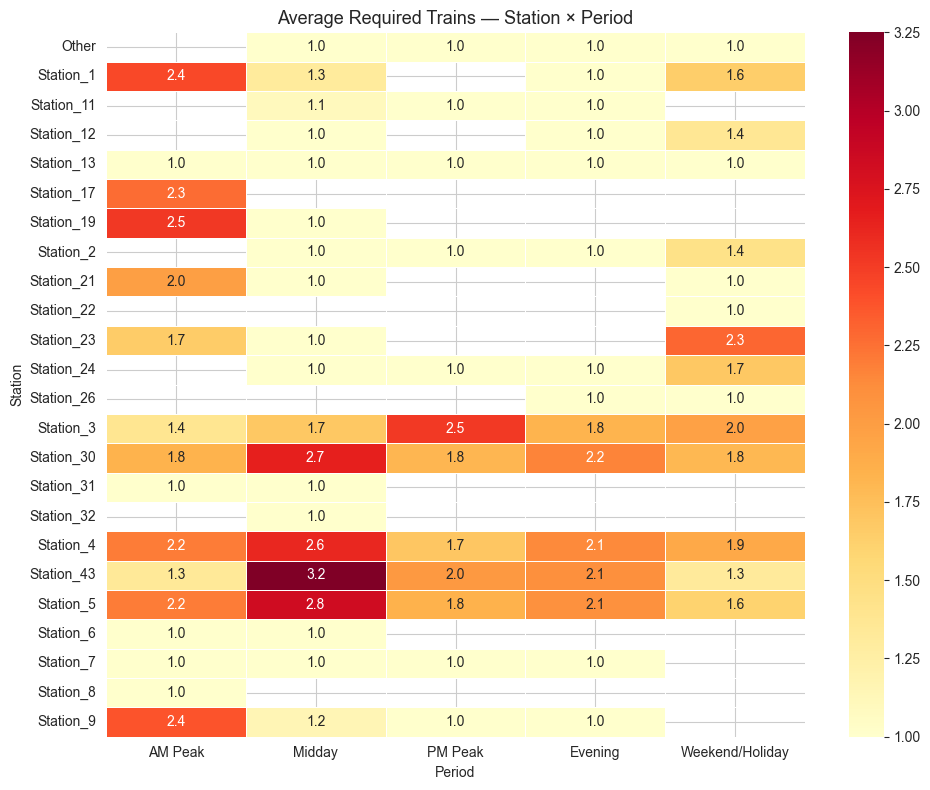

In [23]:
# Heatmap — average required trains per station and time period
PERIOD_ORDER = ['AM Peak', 'Midday', 'PM Peak', 'Evening', 'Weekend/Holiday']

pivot = allocation_summary.pivot_table(
    index='Station', columns='Period',
    values='required_trains', aggfunc='mean'
)[PERIOD_ORDER]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Required Trains — Station × Period', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Save Model

In [27]:
# Save the trained ElasticNet model
joblib.dump(best_model, '../models/ElasticNet_model/elasticnet_model.pkl')

# Save the fitted preprocessor (needed for inference on new data)
joblib.dump(preprocessor, '../models/ElasticNet_model/preprocessor.pkl')

# Save allocation summary
allocation_summary.to_csv('../data/elasticnet_allocation_summary.csv', index=False)

print('Saved: elasticnet_model.pkl | preprocessor.pkl | elasticnet_allocation_summary.csv')

Saved: elasticnet_model.pkl | preprocessor.pkl | elasticnet_allocation_summary.csv


## Load Model & Run Inference on New Data

In [ ]:
# Load model and preprocessor
loaded_model        = joblib.load('elasticnet_model.pkl')
loaded_preprocessor = joblib.load('preprocessor.pkl')

# --- Example: predict on new_df ---
# new_df = pd.read_csv('../data/new_ridership.csv')
# new_df['date'] = pd.to_datetime(...)
# new_df = add_calendar_features(new_df)
# new_df = create_time_series_features(new_df).dropna()
# _, new_df = target_encode_station(train_df, new_df)  # use original train_df for encoding
#
# X_new     = new_df.drop(columns=['Ridership', 'Station', 'date'])
# X_new_enc = loaded_preprocessor.transform(X_new)
# preds     = loaded_model.predict(X_new_enc)

print('Model loaded. Uncomment the code above to run inference on new data.')

Model loaded. Uncomment the code above to run inference on new data.


In [ ]:
results_df[["Ridership", "predicted_ridership"]]

,Ridership,predicted_ridership
0,161,237.912828
1,54,130.671763
2,124,242.184666
3,271,280.835210
4,24,236.462299
...,...,...
15860,133,116.420284
15861,143,122.442884
15862,478,418.788130
15863,296,249.978994
